In [63]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

### Allen

In [2]:
data = {
    "Gabors": {
        "Linear": [0.46639, 0.39360, 0.49108, 0.46364, 0.42524, 0.42524, 0.41289, 0.40054, 0.39231, 0.39917],
        "RRR": [0.50068, 0.48122, 0.65432, 0.53635, 0.47325, 0.47050, 0.47873, 0.46364, 0.46090, 0.48834],
        "MLP": [0.44856, 0.40195, 0.54458, 0.44307, 0.31962, 0.40192, 0.34979, 0.42661, 0.41975, 0.49657],
        "Multi-Session RRR": [0.49383, 0.50069, 0.64060, 0.53635, 0.48971, 0.45267, 0.48971, 0.48834, 0.45404, 0.51440],
        "Single-Session BMMHMM": [0.46639, 0.44088, 0.59944, 0.49793, 0.42798, 0.41984, 0.40192, 0.38820, 0.38957, 0.40328],
        "Multi-Session BMMHMM": [0.46502, 0.44161, 0.49519, 0.37174, 0.42798, 0.46776, 0.38546, 0.46089, 0.40328, 0.39643],
    },
    "Static Gratings": {
        "Linear": [0.68502, 0.61293, 0.63965, 0.67614, 0.64711, 0.60018, 0.51851, 0.54866, 0.49267, 0.68906],
        "RRR": [0.72547, 0.69568, 0.72068, 0.75968, 0.68533, 0.71575, 0.62101, 0.56072, 0.51593, 0.72523],
        "MLP": [0.66437, 0.67413, 0.69828, 0.77089, 0.66044, 0.65797, 0.56761, 0.56331, 0.50474, 0.70543],
        "Multi-Session RRR": [0.76162, 0.70345, 0.69828, 0.78469, 0.73956, 0.75676, 0.65375, 0.60465, 0.58484, 0.78381],
    },
    "Running Speed": {
        "Linear": [0.44724, 0.53196, 0.72658, 0.52124, 0.57719, 0.01387, -0.41608, -0.20689, 0.43270, 0.51134],
        "RRR": [0.65419, 0.81828, 0.87231, 0.76080, 0.82936, 0.17073, -0.36264, 0.10701, 0.70335, 0.72624],
        "MLP": [0.60498, 0.78574, 0.84387, 0.74018, 0.73723, -0.20081, -0.44179, 0.06848, 0.81140, 0.67291],
        "Multi-Session RRR": [0.69050, 0.85960, 0.87944, 0.77389, 0.83225, 0.38066, -0.33104, -0.01167, 0.81590, 0.74219],
    },
}

/local/ipykernel_3130056/263389141.py:54: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_benchmark.png', dpi=300)
/local/ipykernel_3130056/263389141.py:54: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_benchmark.png', dpi=300)
/local/ipykernel_3130056/263389141.py:54: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_benchmark.png', dpi=300)
/local/ipykernel_3130056/263389141.py:54: Matpl

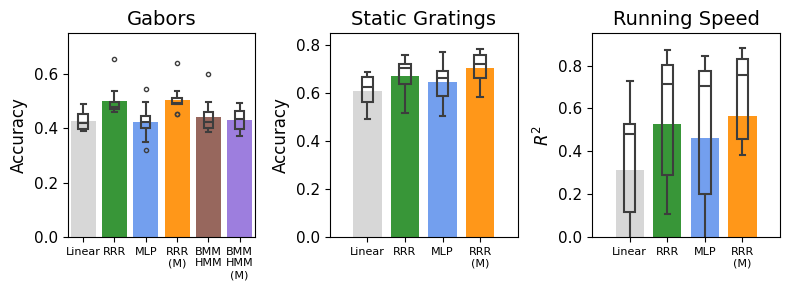

In [5]:
colors = ['lightgray', 'forestgreen', 'cornflowerblue', 'darkorange', 'tab:brown', 'mediumpurple']


fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=False)

for ax, (title, values) in zip(axes, data.items()):
    num_bars = len(values)
    x = np.arange(num_bars)

    # Bar plot
    if title == 'Gabors':
        width = 0.8
    elif title == 'Static Gratings':
        width = 0.75
    elif title == 'Running Speed':
        width = 0.75
    ax.bar(x, np.mean(list(values.values()), axis=1), width=width, capsize=5, color=colors[:num_bars], alpha=0.9, label='Bar Plot')

    # Box plot overlay
    box_data = list(values.values())
    if title != 'Running Speed':
        sns.boxplot(data=box_data, ax=ax, width=0.3, linewidth=1.5, fliersize=3, whis=1.5, boxprops={'facecolor': 'none'})
    else:
        sns.boxplot(data=box_data, ax=ax, width=0.3, linewidth=1.5, fliersize=3, whis=0.8, boxprops={'facecolor': 'none'})

    ax.set_title(title, fontsize=14)
    ax.set_xticks(x)
    
    if title == 'Gabors':
        ax.set_xticklabels(
            ['Linear', 'RRR', 'MLP', 'RRR\n(M)', 'BMM\nHMM', 'BMM\nHMM\n(M)'], 
        )
    else:
        ax.set_xticklabels(
            ['Linear', 'RRR', 'MLP', 'RRR\n(M)'], 
        )

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=11)

    if title == 'Gabors':
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_ylim(0, 0.75)
    elif title == 'Static Gratings':
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.set_ylim(0, 0.85)
        ax.set_xlim(-1, 4)
    elif title == 'Running Speed':
        ax.set_ylabel(r'$R^2$', fontsize=12)
        ax.set_ylim(0, 0.95)
        ax.set_xlim(-1, 4)

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_benchmark.png', dpi=300)
plt.show()

In [67]:
eid = "737581020"

behave_dict = {}
for method in ['linear', 'reduced_rank', 'mlp', 'multi-session']:
    behave_dict[method] = {}
    gt, pred = [], []
    for beh in ["running_speed"]:
        if method == "multi-session":
            data = np.load(f"/burg/stats/users/yz4123/allen/results/multi-session/{beh}/reduced_rank/all/{eid}.npy", allow_pickle=True).item()
        else:
            data = np.load(f"/burg/stats/users/yz4123/allen/results/{eid}/{beh}/{method}/all/{eid}.npy", allow_pickle=True).item()
        test_y = data["test_y"].reshape(-1, 100, 1)
        test_pred = data["test_pred"].reshape(-1, 100, 1)
        gt.append(test_y)
        pred.append(test_pred)
    behave_dict[method]["gt"] = np.concatenate(gt, axis=-1)
    behave_dict[method]["pred"] = np.concatenate(pred, axis=-1)
    

Linear speed: 0.36
RRR speed: 0.55
MLP speed: 0.52


RRR (M) speed: 0.69


/local/ipykernel_1597501/2480126794.py:43: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_traces.png', dpi=400)
/local/ipykernel_1597501/2480126794.py:43: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_traces.png', dpi=400)
/local/ipykernel_1597501/2480126794.py:43: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_traces.png', dpi=400)
/local/ipykernel_1597501/2480126794.py:43: Matplotlib

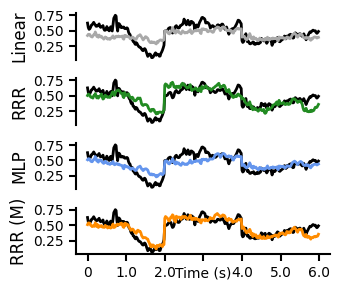

In [82]:
from sklearn.metrics import r2_score

METHOD_NAME = {"linear": "Linear", "reduced_rank": "RRR", "mlp": "MLP", "multi-session": "RRR (M)"}
COLORS = ['darkgray', 'forestgreen', 'cornflowerblue', 'darkorange']

start_time = 500
end_time = start_time + 300

fig, axs = plt.subplots(4, 1, sharex=False, sharey=True, figsize=(3.5, 3))

for i, method in enumerate(['linear', 'reduced_rank', 'mlp', 'multi-session']):

    gt_dim_0 = behave_dict[method]["gt"][...,0].flatten()[start_time:end_time]
    pred_dim_0 = behave_dict[method]["pred"][...,0].flatten()[start_time:end_time]

    print(f"{METHOD_NAME[method]} speed: {r2_score(gt_dim_0, pred_dim_0):.2f}")

    axs[i].plot(behave_dict[method]["gt"][...,0].flatten()[start_time:end_time], color="k", linewidth=2)
    axs[i].plot(behave_dict[method]["pred"][...,0].flatten()[start_time:end_time], color=COLORS[i], linewidth=2)
    axs[i].set_ylabel(METHOD_NAME[method], fontsize=12)

    for spine in axs[i].spines.values():
        spine.set_linewidth(1.5)
        axs[i].tick_params(axis='x', width=1.5, length=5)
        axs[i].tick_params(axis='y', width=1.5, length=5)

    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    # Remove bottom spine except for the last row
    if i < 3:  # For all rows except the last one
        axs[i].spines['bottom'].set_visible(False)
        axs[i].set_xticks([])  # Remove x-axis ticks
        axs[i].set_xticklabels([])

    axs[-1].set_xticks([0, 50, 100, 150, 200, 250, 300])
    axs[-1].set_xticklabels(
        ["0", "1.0", "2.0", "Time (s)", "4.0", "5.0", "6.0"], fontsize=10
    )
    axs[i].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/allen_traces.png', dpi=400)
plt.show()

### IBL Unaligned

In [61]:
data = {
    "Wheel Speed": {
        "Linear": [0.46276, -0.19201, 0.19627, 0.57647, 0.13538, 0.37261, 0.29080, -0.11621, 0.10463, 0.03722],
        "RRR": [0.52114, 0.37647, 0.33357, 0.62890, 0.33908, 0.37356, 0.41544, 0.33174, 0.33783, 0.42258],
        "MLP": [0.22111, 0.36075, 0.37303, 0.69723, 0.36656, 0.46497, 0.39843, 0.39142, 0.29702, 0.42024],
        "Multi-Session RRR": [0.51780, 0.44017, 0.36408, 0.61673, 0.40009, 0.47449, 0.48409, 0.31873, 0.34676, 0.45059],
    },
    "Whisker Motion Energy": {
        "Linear": [0.59393, 0.26418, 0.63112, 0.60190, 0.45134, 0.75343, 0.59452, 0.44611, 0.18052, 0.05190],
        "RRR": [0.63682, 0.71027, 0.74563, 0.69613, 0.62445, 0.80845, 0.68807, 0.62931, 0.60276, 0.68707],
        "MLP": [0.69954, 0.76411, 0.75570, 0.66969, 0.61756, 0.80253, 0.71768, 0.68325, 0.63752, 0.62355],
        "Multi-Session RRR": [0.66906, 0.74496, 0.75786, 0.69942, 0.62304, 0.81715, 0.71234, 0.62377, 0.61910, 0.70182],
    },
}

/local/ipykernel_3052364/2836392924.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_benchmark.png', dpi=300)
/local/ipykernel_3052364/2836392924.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_benchmark.png', dpi=300)
/local/ipykernel_3052364/2836392924.py:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_benchmark.png', dpi=300)
/local/ipykernel_305

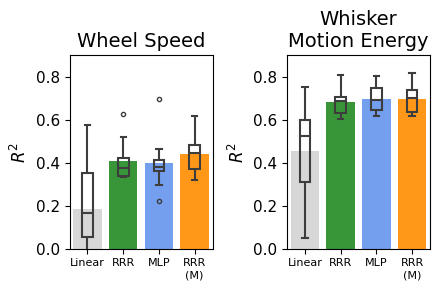

In [75]:
colors = ['lightgray', 'forestgreen', 'cornflowerblue', 'darkorange']


fig, axes = plt.subplots(1, 2, figsize=(4.5, 3), sharey=False)

for ax, (title, values) in zip(axes, data.items()):
    num_bars = len(values)
    x = np.arange(num_bars)

    # Bar plot
    width = 0.8
    ax.bar(x, np.mean(list(values.values()), axis=1), width=width, capsize=5, color=colors[:num_bars], alpha=0.9, label='Bar Plot')

    # Box plot overlay
    box_data = list(values.values())
    sns.boxplot(
        data=box_data, ax=ax, width=0.3, linewidth=1.5, fliersize=3, whis=1.5, boxprops={'facecolor': 'none'},
    )
    if title == 'Wheel Speed':
        ax.set_title(title, fontsize=14)
    else:
        ax.set_title("Whisker\nMotion Energy", fontsize=14)
    ax.set_xticks(x)
    
    ax.set_xticklabels(
        ['Linear', 'RRR', 'MLP', 'RRR\n(M)'], 
    )

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=11)

    ax.set_ylabel(r'$R^2$', fontsize=12)
    ax.set_ylim(0, 0.9)
    # ax.set_xlim(-1, 4)

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_benchmark.png', dpi=300)
plt.show()

In [27]:
eid = "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b"

behave_dict = {}
for method in ['linear', 'reduced_rank', 'mlp', 'multi-session']:
    behave_dict[method] = {}
    gt, pred = [], []
    for beh in ["wheel-speed", "whisker-motion-energy"]:
        if method == "multi-session":
            data = np.load(f"/burg/stats/users/yz4123/Downloads/ibl_unaligned/multi-session/{beh}/reduced_rank/all/{eid}.npy", allow_pickle=True).item()
        else:
            data = np.load(f"/burg/stats/users/yz4123/Downloads/ibl_unaligned/{eid}/{beh}/{method}/all/{eid}.npy", allow_pickle=True).item()
        test_y = data["test_y"].reshape(-1, 100, 1)
        test_pred = data["test_pred"].reshape(-1, 100, 1)
        if beh == "whisker-motion-energy":
            test_y /= 4
            test_pred /= 4
        gt.append(test_y)
        pred.append(test_pred)
    behave_dict[method]["gt"] = np.concatenate(gt, axis=-1)
    behave_dict[method]["pred"] = np.concatenate(pred, axis=-1)
    

Linear wheel: 0.24, whisker: 0.55
RRR wheel: 0.49, whisker: 0.75
MLP wheel: 0.52, whisker: 0.75
RRR (M) wheel: 0.55, whisker: 0.80


/local/ipykernel_1597501/4184962880.py:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_traces.png', dpi=400)
/local/ipykernel_1597501/4184962880.py:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_traces.png', dpi=400)
/local/ipykernel_1597501/4184962880.py:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_traces.png', dpi=400)
/local/ipykernel_1597501/4184

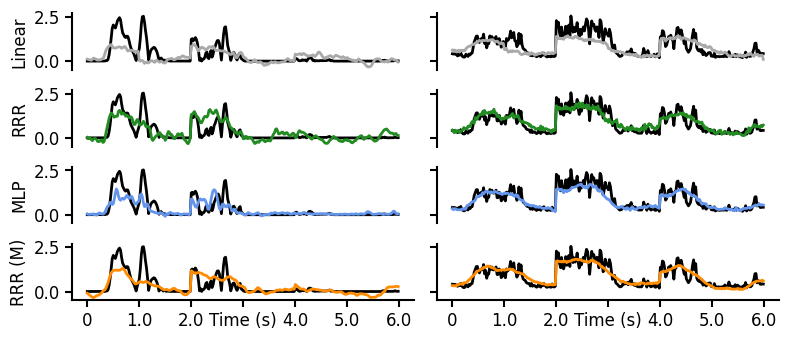

In [50]:
from sklearn.metrics import r2_score

METHOD_NAME = {"linear": "Linear", "reduced_rank": "RRR", "mlp": "MLP", "multi-session": "RRR (M)"}
COLORS = ['darkgray', 'forestgreen', 'cornflowerblue', 'darkorange']

start_time = 0
end_time = start_time + 300

fig, axs = plt.subplots(4, 2, sharex=False, sharey=True, figsize=(8, 3.5))

for i, method in enumerate(['linear', 'reduced_rank', 'mlp', 'multi-session']):

    gt_dim_0 = behave_dict[method]["gt"][...,0].flatten()[start_time:end_time]
    gt_dim_1 = behave_dict[method]["gt"][...,1].flatten()[start_time:end_time]
    pred_dim_0 = behave_dict[method]["pred"][...,0].flatten()[start_time:end_time]
    pred_dim_1 = behave_dict[method]["pred"][...,1].flatten()[start_time:end_time]

    print(f"{METHOD_NAME[method]} wheel: {r2_score(gt_dim_0, pred_dim_0):.2f}, whisker: {r2_score(gt_dim_1, pred_dim_1):.2f}")

    axs[i][0].plot(behave_dict[method]["gt"][...,0].flatten()[start_time:end_time], color="k", linewidth=2)
    axs[i][1].plot(behave_dict[method]["gt"][...,1].flatten()[start_time:end_time], color="k", linewidth=2)
    axs[i][0].plot(behave_dict[method]["pred"][...,0].flatten()[start_time:end_time], color=COLORS[i], linewidth=2)
    axs[i][1].plot(behave_dict[method]["pred"][...,1].flatten()[start_time:end_time], color=COLORS[i], linewidth=2)
    axs[i][0].set_ylabel(METHOD_NAME[method], fontsize=12)

    # Remove top and right spines for both subplots in this row
    for j in range(2):

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
            axs[i][j].tick_params(axis='x', width=1.5, length=5)
            axs[i][j].tick_params(axis='y', width=1.5, length=5)

        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)

        # Remove bottom spine except for the last row
        if i < 3:  # For all rows except the last one
            axs[i][j].spines['bottom'].set_visible(False)
            axs[i][j].set_xticks([])  # Remove x-axis ticks
            axs[i][j].set_xticklabels([])

        axs[-1][j].set_xticks([0, 50, 100, 150, 200, 250, 300])
        axs[-1][j].set_xticklabels(
            ["0", "1.0", "2.0", "Time (s)", "4.0", "5.0", "6.0"], fontsize=12
        )
        axs[i][j].tick_params(axis='y', labelsize=12)
# axs[0][0].set_title('Wheel Speed', fontsize=14)
# axs[0][1].set_title('Whisker Motion Energy', fontsize=14)

plt.tight_layout()
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/ibl_unaligned_traces.png', dpi=400)
plt.show()

### MC-RTT

In [5]:
behave_dict = {}
for method in ['linear', 'reduced_rank', 'mlp']:
    behave_dict[method] = {}
    gt, pred = [], []
    for dim in [0, 1]:
        data = np.load(f"/burg/stats/users/yz4123/Downloads/results/nlb-rtt/finger_vel_dim_{dim}/{method}/all/nlb-rtt_binSize5.npy", allow_pickle=True).item()
        gt.append(data["test_y"].reshape(-1, 600, 1))
        pred.append(data["test_pred"].reshape(-1, 600, 1))
    behave_dict[method]["gt"] = np.concatenate(gt, axis=-1)
    behave_dict[method]["pred"] = np.concatenate(pred, axis=-1)
    

Linear dim 0: -0.28, dim 1: 0.19
RRR dim 0: -0.20, dim 1: -0.08
MLP dim 0: -0.13, dim 1: 0.14


/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  fig.canvas.print_figure(bytes_io, **kw)
/burg/home/yz4123/.conda/envs/decoding/lib/python3.11

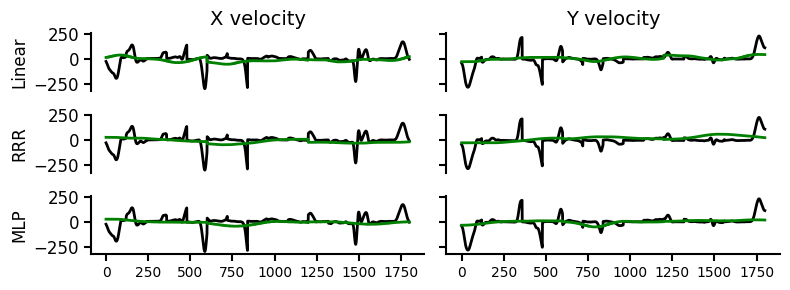

In [12]:
from sklearn.metrics import r2_score

METHOD_NAME = {"linear": "Linear", "reduced_rank": "RRR", "mlp": "MLP"}

start_time = 1800
end_time = start_time + 1800

fig, axs = plt.subplots(3, 2, sharex=False, sharey=True, figsize=(8, 3))

for i, method in enumerate(['linear', 'reduced_rank', 'mlp']):

    gt_dim_0 = behave_dict[method]["gt"][...,0].flatten()[start_time:end_time]
    gt_dim_1 = behave_dict[method]["gt"][...,1].flatten()[start_time:end_time]
    pred_dim_0 = behave_dict[method]["pred"][...,0].flatten()[start_time:end_time]
    pred_dim_1 = behave_dict[method]["pred"][...,1].flatten()[start_time:end_time]

    print(f"{METHOD_NAME[method]} dim 0: {r2_score(gt_dim_0, pred_dim_0):.2f}, dim 1: {r2_score(gt_dim_1, pred_dim_1):.2f}")

    axs[i][0].plot(behave_dict[method]["gt"][...,0].flatten()[start_time:end_time], color="k", linewidth=2)
    axs[i][1].plot(behave_dict[method]["gt"][...,1].flatten()[start_time:end_time], color="k", linewidth=2)
    axs[i][0].plot(behave_dict[method]["pred"][...,0].flatten()[start_time:end_time], color="green", linewidth=2)
    axs[i][1].plot(behave_dict[method]["pred"][...,1].flatten()[start_time:end_time], color="green", linewidth=2)
    axs[i][0].set_ylabel(METHOD_NAME[method], fontsize=12)

    # Remove top and right spines for both subplots in this row
    for j in range(2):

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
            axs[i][j].tick_params(axis='x', width=1.5, length=5)
            axs[i][j].tick_params(axis='y', width=1.5, length=5)

        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)

        # Remove bottom spine except for the last row
        if i < 2:  # For all rows except the last one
            axs[i][j].spines['bottom'].set_visible(False)
            axs[i][j].set_xticks([])  # Remove x-axis ticks
            axs[i][j].set_xticklabels([])

        # axs[-1][j].set_xticks([0, 50, 100, 150, 200, 250, 300])
        # axs[-1][j].set_xticklabels(
        #     ["0", "1.0", "2.0", "Time (s)", "4.0", "5.0", "6.0"], fontsize=12
        # )
        axs[i][j].tick_params(axis='y', labelsize=12)
axs[0][0].set_title('X velocity', fontsize=14)
axs[0][1].set_title('Y velocity', fontsize=14)

plt.tight_layout()
# plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/mc_rtt_finger_vel.png', dpi=400)
plt.show()

### MC-RTT

In [66]:
# x velocity
# data = {
#     "Finger Velocity": {
#         "Linear": [0.31587, 0.32156, 0.31205, 0.2833, 0.3139],
#         "RRR": [0.40069, 0.41449, 0.40154, 0.38098, 0.3849],
#         "MLP": [0.46506, 0.44708, 0.46512, 0.41344, 0.44514],
#     },
# }

# y velocity
data = {
    "Finger Velocity": {
        "Linear": [0.31541, 0.35118, 0.35564, 0.29465, 0.26181],
        "RRR": [0.41212, 0.44109, 0.45433, 0.38899, 0.38467],
        "MLP": [0.45291, 0.50946, 0.48391, 0.45409, 0.47579],
    },
}

/local/ipykernel_2066346/1470950527.py:38: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/nlb_rtt_yvel_benchmark.png', dpi=300)
/local/ipykernel_2066346/1470950527.py:38: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/nlb_rtt_yvel_benchmark.png', dpi=300)
/local/ipykernel_2066346/1470950527.py:38: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/nlb_rtt_yvel_benchmark.png', dpi=300)
/local/ipykernel_206634

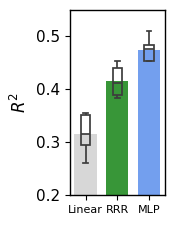

In [67]:
colors = ['lightgray', 'forestgreen', 'cornflowerblue']


fig, ax = plt.subplots(1, 1, figsize=(2, 2.5), sharey=False)

title = "Finger Velocity"
values = data[title]
num_bars = len(values)
x = np.arange(num_bars)

# Bar plot
width = 0.7
ax.bar(x, np.mean(list(values.values()), axis=1), width=width, capsize=5, color=colors[:num_bars], alpha=0.9, label='Bar Plot')

# Box plot overlay
box_data = list(values.values())
sns.boxplot(
    data=box_data, ax=ax, width=0.3, linewidth=1.25, fliersize=3, whis=1.5, boxprops={'facecolor': 'none'},
)

# ax.set_title(title, fontsize=14)
ax.set_xticks(x)

ax.set_xticklabels(
    ['Linear', 'RRR', 'MLP'], 
)

ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=11)

ax.set_ylabel(r'$R^2$', fontsize=12)
ax.set_ylim(0.2, 0.55)
ax.set_xlim(-.5, 2.5)
ax.set_yticks(np.arange(0.2, 0.55, 0.1))

plt.tight_layout()
# plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/nlb_rtt_xvel_benchmark.png', dpi=300)
plt.savefig('/burg/stats/users/yz4123/neural_decoding/notebooks/figs/nlb_rtt_yvel_benchmark.png', dpi=300)
plt.show()